In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma, gammaincc, erf, ndtr

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1780404831.742030 1034662 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780404831.905765 1034662 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780404833.476743 1034662 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780404835.418763 1034662 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
# metadata_train = pq.read_metadata('../../Cross Validation Data/train_data_small.parquet')
# metadata_test = pq.read_metadata('../../Cross Validation Data/test_data_small.parquet')
metadata_train = pq.read_metadata('../../train_data.parquet')
metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

94 features
9997300 colunas - Treino
3124157 colunas - Teste


In [3]:
# Parquet file path
# parquet_file_path_train = "../../Cross Validation Data/train_data_small.parquet"
# parquet_file_path_test = "../../Cross Validation Data/test_data_small.parquet"
parquet_file_path_train = "../../train_data.parquet"
parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

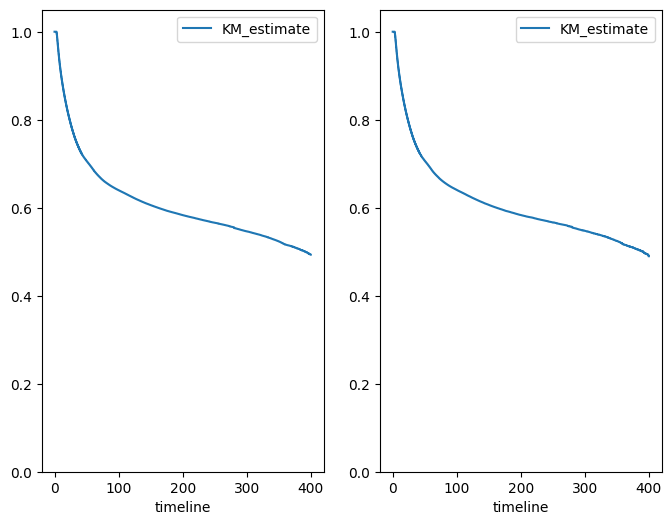

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

In [5]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

# Custom Mixture Inverse-Gaussian

In [6]:
def build_custom_mixture_invgaussian_model(ridge_penalty=1e-4, lasso_penalty=1e-4):
    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )
    
    parameters = {
        # Inverse Gaussian component (mu: mean, lam_ig: shape/dispersion)
        "mu": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "lam_ig": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        
        # Weibull component
        "k": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 30.0, "warmup_time": 0},
        "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 35.0, "warmup_time": 0},
        
        # Mixture weight
        "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "independent", "shape": 1, "init": 0.55, "warmup_time": 0}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps
        log_y = tf.math.log(y_safe)

        # 1. Extract parameters
        mu = model.get_variable("mu", nn_output)
        lam_ig_raw = model.get_variable("lam_ig", nn_output)
        k_raw = model.get_variable("k", nn_output)
        lam = model.get_variable("lam", nn_output)
        w = model.get_variable("w")

        # 2. Prevent singularity collapses
        lam_ig = tf.clip_by_value(lam_ig_raw, 0.1, 50.0)
        k = tf.clip_by_value(k_raw, 0.1, 50.0)

        # -------------------------------------------------------------
        # Log-density and log-survival for the INVERSE GAUSSIAN component
        # -------------------------------------------------------------
        value_2pi = 2.0 * tf.cast(np.pi, dtype=tf.float32)
        
        # Log-Density: 0.5*log(lam) - 0.5*log(2*pi) - 1.5*log(t) - [lam*(t - mu)^2 / (2 * mu^2 * t)]
        term1 = 0.5 * tf.math.log(lam_ig + eps)
        term2 = -0.5 * tf.math.log(value_2pi)
        term3 = -1.5 * log_y
        term4 = -(lam_ig * (y_safe - mu)**2.0) / (2.0 * (mu**2.0) * y_safe)
        
        log_f1 = term1 + term2 + term3 + term4

        # Survival Function: Phi(z1) - exp(2*lam/mu) * Phi(z2)
        sqrt_lam_y = tf.math.sqrt(lam_ig / y_safe)
        z1 = sqrt_lam_y * (1.0 - (y_safe / mu))
        z2 = -sqrt_lam_y * (1.0 + (y_safe / mu))
        
        # Clip the exponent to prevent overflow in float32
        sqrt_2 = tf.math.sqrt(2.0)
        cdf_z1 = 0.5 * (1.0 + tf.math.erf(z1 / sqrt_2))
        cdf_z2 = 0.5 * (1.0 + tf.math.erf(z2 / sqrt_2))

        safe_exponent = tf.clip_by_value(2.0 * lam_ig / mu, -80.0, 80.0)
        exp_term = tf.math.exp(safe_exponent)
        
        # Calculate raw survival probability and clip to [0, 1] to fix float precision drops
        S1 = tf.clip_by_value(cdf_z1 - (exp_term * cdf_z2), 0.0, 1.0)
        log_S1 = tf.math.log(S1 + eps)

        # -------------------------------------------------------------
        # Log-density and log-survival for the WEIBULL component
        # -------------------------------------------------------------
        log_S2 = -(y_safe / lam)**k
        log_f2 = tf.math.log(k + eps) - (k * tf.math.log(lam)) + ((k - 1.0) * log_y) + log_S2

        # -------------------------------------------------------------
        # Mixture Assembly
        # -------------------------------------------------------------
        log_w = tf.math.log(w + eps)
        log_1_minus_w = tf.math.log(1.0 - w + eps)
        
        f_stack = tf.concat([log_w + log_f1, log_1_minus_w + log_f2], axis=1)
        S_stack = tf.concat([log_w + log_S1, log_1_minus_w + log_S2], axis=1)

        log_f_mix = tf.math.reduce_logsumexp(f_stack, axis=1, keepdims=True)
        log_S_mix = tf.math.reduce_logsumexp(S_stack, axis=1, keepdims=True)
        
        # Custom Mixture Log-Likelihood
        loglik_terms = (delta * log_f_mix) + ((1.0 - delta) * log_S_mix)
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    return parameters, loglikelihood_loss, None, None, None

In [7]:
with tf.device("/GPU:0"):
    custom_mixture_parameters, custom_mixture_loss, custom_mixture_neural_network, custom_mixture_call, custom_mixture_call_nolast = \
    build_custom_mixture_invgaussian_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
    seed = 10
    custom_mixture_invgaussian_model = thf.ModelNN(custom_mixture_parameters, custom_mixture_loss,
                                                   custom_mixture_neural_network, custom_mixture_call,
                                                   custom_mixture_call_nolast, input_dim = (1,), seed = seed)
    custom_mixture_invgaussian_model.train_model(epochs = 1200, x = None, data = data_train,
                                                 shuffle = True,
                                                 get_covariances = True,
                                                 validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                                 force_training_validation = False,
                                                 optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                                 optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                                 fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                                 early_stopping = True, early_stopping_patience = 30,
                                                 early_stopping_warmup = 10,
                                                 reduce_lr = True, reduce_lr_warmup = 0,
                                                 reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                                                 reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                                 deterministic = True,
                                                 verbose = True, print_freq = 1)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1199 / 1200 ]  | Loss:  1578727.25 | Best Loss:  1578727.25 | Speed:  7  epoch/s    | Elapsed Time:  159.687057  s     
Done.
Extracting covariance structure.
Done.
Optimization finished in 166.202 seconds.


I0000 00:00:1780405019.880495 1034662 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x61550d3c32e0


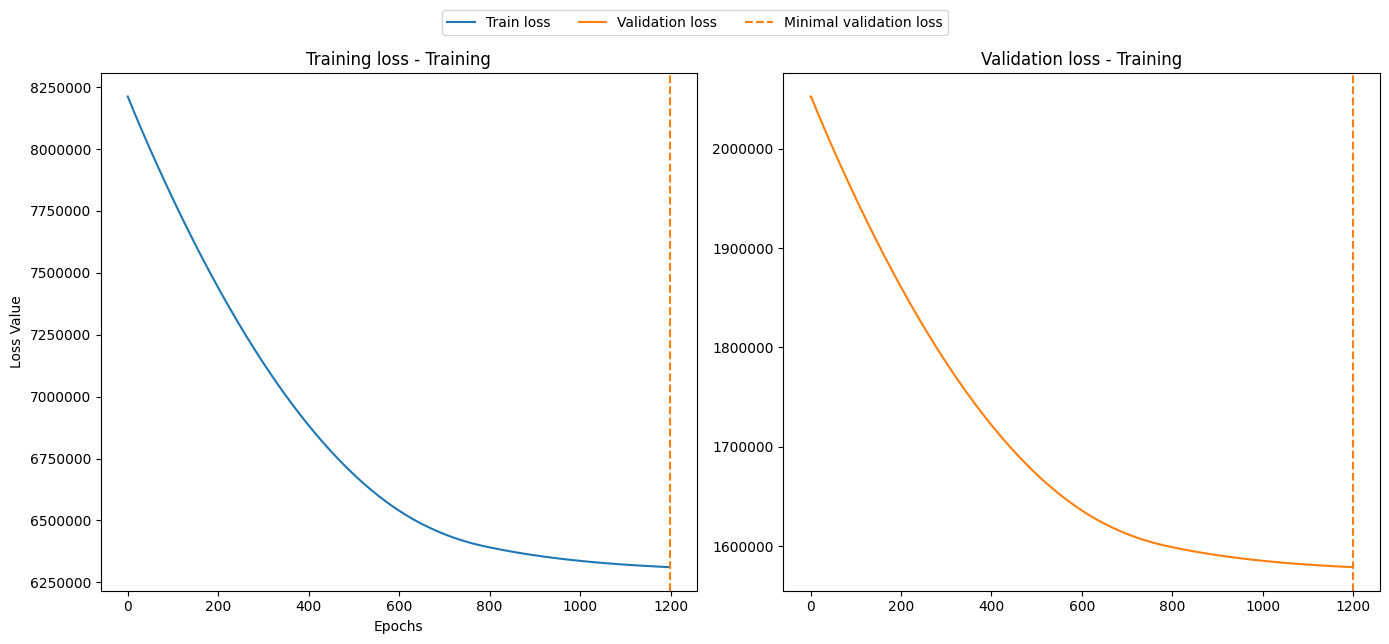

In [8]:
utils.plot_model_convergence( custom_mixture_invgaussian_model )

mu: [3.320108]
lam_ig: [1.8292518]
k: [9.0366125]
lam: [37.78854]
w: [0.39636618]


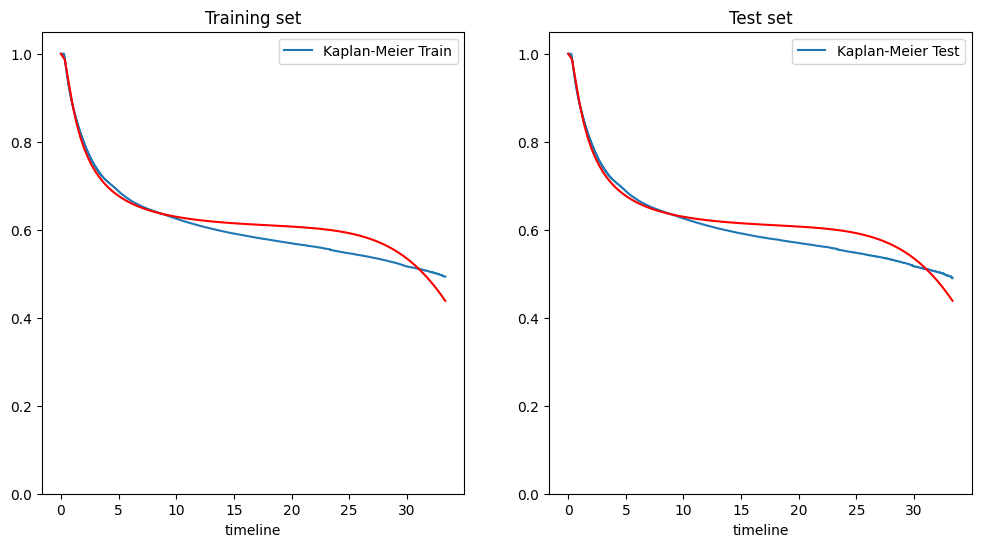

In [9]:
mu = custom_mixture_invgaussian_model.predict("mu")
lam_ig = custom_mixture_invgaussian_model.predict("lam_ig")
k = custom_mixture_invgaussian_model.predict("k")
lam = custom_mixture_invgaussian_model.predict("lam")
w = custom_mixture_invgaussian_model.predict("w")
print("mu:", mu)
print("lam_ig:", lam_ig)
print("k:", k)
print("lam:", lam)
print("w:", w)

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

def calculate_ig_survival(ts, mu, lam_ig):
    # ts is (100, 1), mu and lam_ig are (N,). Operations broadcast to (100, N)
    sqrt_lam_t = np.sqrt(lam_ig / ts)
    z1 = sqrt_lam_t * (1.0 - (ts / mu))
    z2 = -sqrt_lam_t * (1.0 + (ts / mu))
    
    cdf_z1 = ndtr(z1)
    cdf_z2 = ndtr(z2)
    
    # NumPy uses float64, which safely overflows at exp(709). 
    # We clip at 700.0 to prevent RuntimeWarnings during evaluation.
    safe_exponent = np.clip(2.0 * lam_ig / mu, a_min=-700.0, a_max=700.0)
    exp_term = np.exp(safe_exponent)
    
    # Clip the final survival curve to [0, 1] to catch any floating point drifts
    S_ig = np.clip(cdf_z1 - (exp_term * cdf_z2), 0.0, 1.0)
    return S_ig

# Component 1: Inverse Gaussian
S1_ts_train = calculate_ig_survival(ts_grid, mu, lam_ig)
S2_ts_train = np.exp( -(ts_grid / lam)**k )
S_ts_train = w * S1_ts_train + (1 - w) * S2_ts_train

S1_ts_test = calculate_ig_survival(ts_grid, mu, lam_ig)
S2_ts_test = np.exp( -(ts_grid / lam)**k )
S_ts_test = w * S1_ts_test + (1 - w) * S2_ts_test

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

# Custom Mixture Burr Type XII

In [10]:
def build_custom_mixture_burr_model(ridge_penalty=1e-4, lasso_penalty=1e-4):
    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )
    
    parameters = {
        # Burr Type XII component (Component 1)
        # lam_burr: scale, c: peak shape, k_burr: tail shape
        "lam_burr": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 5.0, "warmup_time": 0},
        "c": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 2.0, "warmup_time": 0},
        "k_burr": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        
        # Weibull component (Component 2 - The Cliff)
        "k": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 30.0, "warmup_time": 0},
        "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 35.0, "warmup_time": 0},
        
        # Mixture weight
        "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "independent", "shape": 1, "init": 0.20, "warmup_time": 50}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps
        log_y = tf.math.log(y_safe)

        # 1. Extract parameters
        lam_burr = model.get_variable("lam_burr", nn_output)
        c = model.get_variable("c", nn_output)
        k_burr = model.get_variable("k_burr", nn_output)
        
        k = model.get_variable("k", nn_output)
        lam = model.get_variable("lam", nn_output)
        w = model.get_variable("w")

        # -------------------------------------------------------------
        # Log-density and log-survival for the BURR XII component
        # -------------------------------------------------------------
        log_lam_burr = tf.math.log(lam_burr + eps)
        
        # Stable projection: z = c * (log(y) - log(lam_burr))
        z = c * (log_y - log_lam_burr)
        
        # Log-Survival: -k * log(1 + (y/lam)^c) -> efficiently computed via softplus
        log_S1 = -k_burr * tf.math.softplus(z)
        
        # Log-Density: log(k) + log(c) - log(lam) + (c-1)(log(y) - log(lam)) - (k+1)*log(1+(y/lam)^c)
        log_f1 = (tf.math.log(k_burr + eps) + tf.math.log(c + eps) - log_lam_burr + 
                  ((c - 1.0) * (log_y - log_lam_burr)) - 
                  ((k_burr + 1.0) * tf.math.softplus(z)))

        # -------------------------------------------------------------
        # Log-density and log-survival for the WEIBULL component
        # -------------------------------------------------------------
        log_S2 = -(y_safe / lam)**k
        log_f2 = tf.math.log(k + eps) - (k * tf.math.log(lam)) + ((k - 1.0) * log_y) + log_S2

        # -------------------------------------------------------------
        # Mixture Assembly
        # -------------------------------------------------------------
        log_w = tf.math.log(w + eps)
        log_1_minus_w = tf.math.log(1.0 - w + eps)
        
        f_stack = tf.concat([log_w + log_f1, log_1_minus_w + log_f2], axis=1)
        S_stack = tf.concat([log_w + log_S1, log_1_minus_w + log_S2], axis=1)

        log_f_mix = tf.math.reduce_logsumexp(f_stack, axis=1, keepdims=True)
        log_S_mix = tf.math.reduce_logsumexp(S_stack, axis=1, keepdims=True)
        
        loglik_terms = (delta * log_f_mix) + ((1.0 - delta) * log_S_mix)
        neg_loglik = -tf.reduce_sum(loglik_terms)
        
        return neg_loglik

    return parameters, loglikelihood_loss, None, None, None

In [11]:
with tf.device("/GPU:0"):
    custom_mixture_parameters, custom_mixture_loss, custom_mixture_neural_network, custom_mixture_call, custom_mixture_call_nolast = \
    build_custom_mixture_burr_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
    seed = 10
    custom_mixture_burr_model = thf.ModelNN(custom_mixture_parameters, custom_mixture_loss,
                                             custom_mixture_neural_network, custom_mixture_call,
                                             custom_mixture_call_nolast, input_dim = (1,), seed = seed)
    custom_mixture_burr_model.train_model(epochs = 1200, x = None, data = data_train,
                                           shuffle = True,
                                           get_covariances = True,
                                           validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                           force_training_validation = False,
                                           optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                           optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                           fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                           early_stopping = True, early_stopping_patience = 30,
                                           early_stopping_warmup = 10,
                                           reduce_lr = True, reduce_lr_warmup = 0,
                                           reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                                           reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                           deterministic = True,
                                           verbose = True, print_freq = 1)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1199 / 1200 ]  | Loss:  36007.0391 | Best Loss:  36011.6562 | Speed:  54  epoch/s    | Elapsed Time:  21.8357277  s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 23.412 seconds.


lam_burr: [1.790181]
c: [1.631942]
k_burr: [0.91028064]
k: [9.0366125]
lam: [38.896866]
w: [0.40766463]


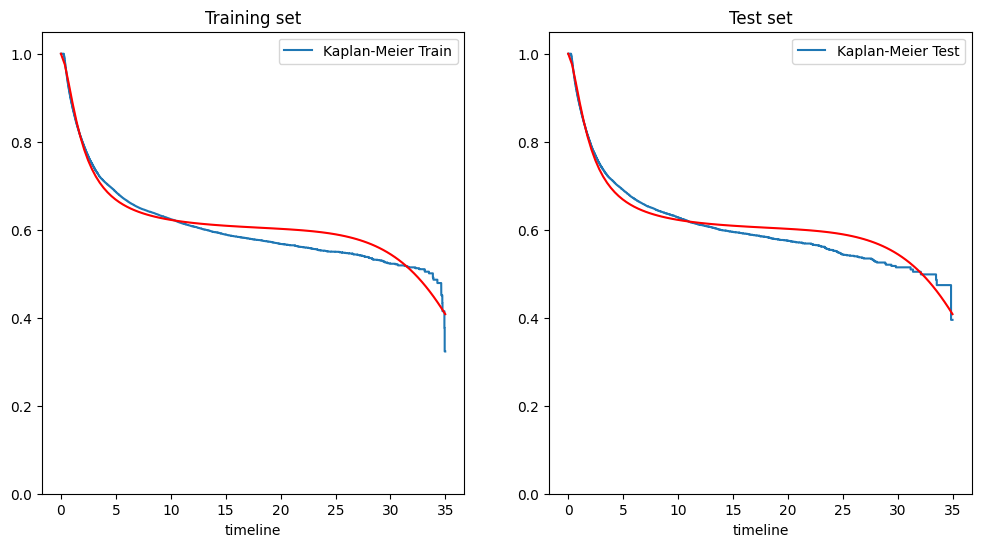

In [12]:
lam_burr = custom_mixture_burr_model.predict("lam_burr")
c = custom_mixture_burr_model.predict("c")
k_burr = custom_mixture_burr_model.predict("k_burr")
k = custom_mixture_burr_model.predict("k")
lam = custom_mixture_burr_model.predict("lam")
w = custom_mixture_burr_model.predict("w")

print("lam_burr:", lam_burr)
print("c:", c)
print("k_burr:", k_burr)
print("k:", k)
print("lam:", lam)
print("w:", w)

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

# Assuming you extracted lam_burr, c, k_burr as numpy arrays
def calculate_burr_survival(ts, lam_burr, c, k_burr):
    # S(t) = (1 + (t / lam)^c)^(-k)
    base = 1.0 + (ts / lam_burr)**c
    S_burr = np.power(base, -k_burr)
    return np.clip(S_burr, 0.0, 1.0)

# Component 1: Inverse Gaussian
S1_ts_train = calculate_burr_survival(ts_grid, lam_burr, c, k_burr)
S2_ts_train = np.exp( -(ts_grid / lam)**k )
S_ts_train = w * S1_ts_train + (1 - w) * S2_ts_train

S1_ts_test = calculate_burr_survival(ts_grid, lam_burr, c, k_burr)
S2_ts_test = np.exp( -(ts_grid / lam)**k )
S_ts_test = w * S1_ts_test + (1 - w) * S2_ts_test

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

# Custom Mixture Log-normal

In [13]:
def build_custom_mixture_lognormal_model(ridge_penalty=1e-4, lasso_penalty=1e-4):
    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )
    
    parameters = {
        # Lognormal component
        "mu": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "sigma": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        # Weibull component
        "k": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 30.0, "warmup_time": 0},
        "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 35.0, "warmup_time": 0},
        # Mixture weight
        "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "independent", "shape": 1, "init": 0.55, "warmup_time": 1200}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        mu = model.get_variable("mu", nn_output)
        sigma = model.get_variable("sigma", nn_output)
        
        # sigma = model.get_variable("sigma")
        k = model.get_variable("k", nn_output)
        # k = model.get_variable("k")
        lam = model.get_variable("lam", nn_output)
        # w = model.get_variable("w", nn_output)
        w = model.get_variable("w")

        log_y = tf.math.log(y_safe)
        z = (log_y - mu) / sigma
        
        # Log-density and log-survival for the lognormal component
        value_2pi = 2.0 * tf.cast(np.pi, dtype = tf.float32)
        log_f1 = -log_y - tf.math.log(sigma+eps) - tf.math.log(value_2pi) / 2.0 - z**2.0 / 2.0
        log_S1 = tf.math.log( 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0)) + eps )

        # log_beta = tf.math.log(beta + eps)
        # log_alpha = tf.math.log(alpha + eps)
        # log_term = tf.math.softplus( beta * (log_y - log_alpha) )
        # log_f1 = log_beta + (beta-1) * log_y - beta * log_alpha - 2.0 * log_term
        # log_S1 = -log_term

        # Log-density and log-survival for the weibull component
        log_S2 = -(y_safe / lam)**k
        log_f2 = tf.math.log(k+eps) - k * tf.math.log(lam) + (k-1)*log_y + log_S2

        # Apply the LogSumExp trick for the mixture density and survival logs, respectively
        log_w = tf.math.log(w + eps)
        log_1_minus_w = tf.math.log(1.0 - w + eps)
        f_stack = tf.concat([log_w + log_f1, log_1_minus_w + log_f2], axis=1)
        S_stack = tf.concat([log_w + log_S1, log_1_minus_w + log_S2], axis=1)

        log_f_mix = tf.math.reduce_logsumexp(f_stack, axis = 1, keepdims = True)
        log_S_mix = tf.math.reduce_logsumexp(S_stack, axis = 1, keepdims = True)
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f_mix + (1-delta) * log_S_mix
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    return parameters, loglikelihood_loss, None, None, None

In [14]:
with tf.device("/GPU:0"):
    custom_mixture_parameters, custom_mixture_loss, custom_mixture_neural_network, custom_mixture_call, custom_mixture_call_nolast = \
    build_custom_mixture_lognormal_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
    seed = 10
    custom_mixture_lognormal_model = thf.ModelNN(custom_mixture_parameters, custom_mixture_loss,
                                       custom_mixture_neural_network, custom_mixture_call,
                                       custom_mixture_call_nolast, input_dim = (1,), seed = seed)
    custom_mixture_lognormal_model.train_model(epochs = 1200, x = None, data = data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                     force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                     fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                     early_stopping = True, early_stopping_patience = 30,
                                     early_stopping_warmup = 10,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 290 / 1200 ]  | Loss:  36040.3477 | Best Loss:  36042.2266 | Speed:  55  epoch/s    | Elapsed Time:  5.24609661  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.718 seconds.


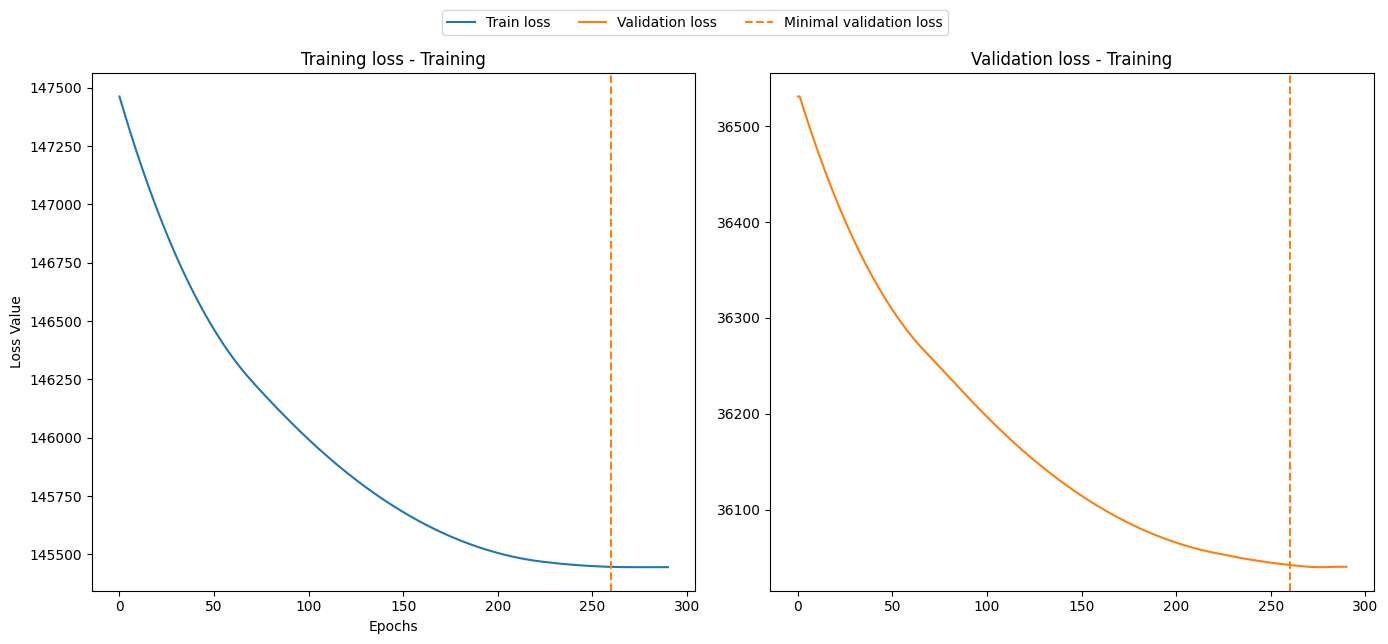

In [15]:
utils.plot_model_convergence( custom_mixture_lognormal_model )

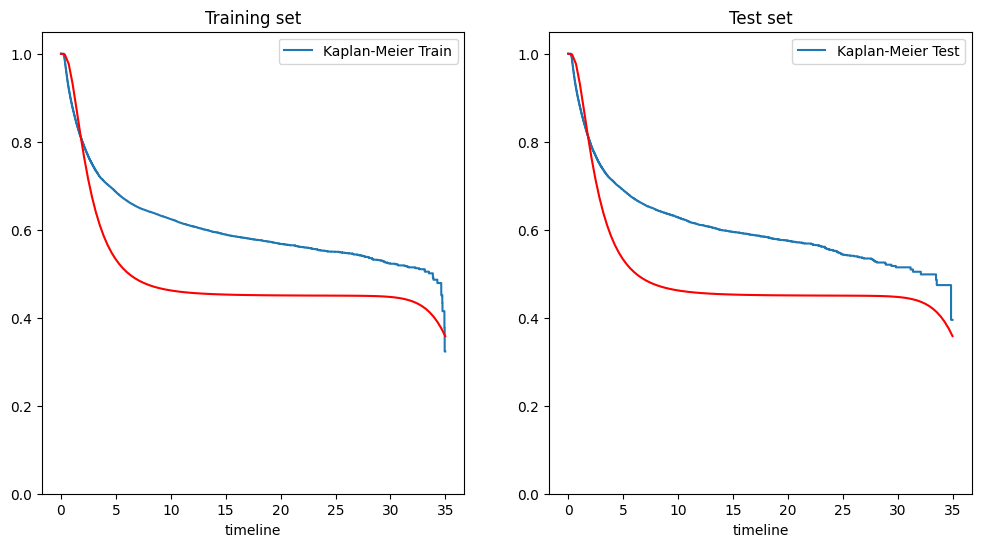

In [16]:
mu = custom_mixture_lognormal_model.predict("mu")
sigma = custom_mixture_lognormal_model.predict("sigma")
k = custom_mixture_lognormal_model.predict("k")
lam = custom_mixture_lognormal_model.predict("lam")
w = custom_mixture_lognormal_model.predict("w")

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

S1_ts_train = 0.5 * (1 - erf(np.log(ts_grid) - mu / sigma))
S2_ts_train = np.exp( -(ts_grid / lam)**k )
S_ts_train = w * S1_ts_train + (1 - w) * S2_ts_train

S1_ts_test = 0.5 * (1 - erf(np.log(ts_grid) - mu / sigma))
S2_ts_test = np.exp( -(ts_grid / lam)**k )
S_ts_test = w * S1_ts_test + (1 - w) * S2_ts_test

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

# Custom Mixture Log-logistic

In [17]:
def build_custom_mixture_loglogistic_model(ridge_penalty=1e-4, lasso_penalty=1e-4):
    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )
    
    parameters = {
        # Loglogistic component
        "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        # Weibull component
        "k": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 30.0, "warmup_time": 0},
        "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 35.0, "warmup_time": 0},
        # Mixture weight
        # "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0},
        "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "independent", "shape": 1, "init": 0.55, "warmup_time": 0}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # mu = model.get_variable("mu", nn_output)
        # sigma = model.get_variable("sigma", nn_output)

        alpha = model.get_variable("alpha")
        beta = model.get_variable("beta")
        
        # sigma = model.get_variable("sigma")
        k = model.get_variable("k")
        # k = model.get_variable("k")
        lam = model.get_variable("lam")
        
        # w = model.get_variable("w", nn_output)
        w = model.get_variable("w")

        log_y = tf.math.log(y_safe)
        # z = (log_y - mu) / sigma
        
        # Log-density and log-survival for the lognormal component
        # value_2pi = 2.0 * tf.cast(np.pi, dtype = tf.float32)
        # log_f1 = -log_y - tf.math.log(sigma+eps) - tf.math.log(value_2pi) / 2.0 - z**2.0 / 2.0
        # log_S1 = tf.math.log( 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0)) + eps )

        log_beta = tf.math.log(beta + eps)
        log_alpha = tf.math.log(alpha + eps)
        log_term = tf.math.softplus( beta * (log_y - log_alpha) )
        log_f1 = log_beta + (beta-1) * log_y - beta * log_alpha - 2.0 * log_term
        log_S1 = -log_term

        # Log-density and log-survival for the weibull component
        log_S2 = -(y_safe / lam)**k
        log_f2 = tf.math.log(k+eps) - k * tf.math.log(lam) + (k-1)*log_y + log_S2

        # Apply the LogSumExp trick for the mixture density and survival logs, respectively
        log_w = tf.math.log(w + eps)
        log_1_minus_w = tf.math.log(1.0 - w + eps)
        f_stack = tf.concat([log_w + log_f1, log_1_minus_w + log_f2], axis=1)
        S_stack = tf.concat([log_w + log_S1, log_1_minus_w + log_S2], axis=1)

        log_f_mix = tf.math.reduce_logsumexp(f_stack, axis = 1, keepdims = True)
        log_S_mix = tf.math.reduce_logsumexp(S_stack, axis = 1, keepdims = True)
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f_mix + (1-delta) * log_S_mix
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    # return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast
    return parameters, loglikelihood_loss, None, None, None

In [18]:
with tf.device("/GPU:0"):
    custom_mixture_parameters, custom_mixture_loss, custom_mixture_neural_network, custom_mixture_call, custom_mixture_call_nolast = \
    build_custom_mixture_loglogistic_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
    seed = 10
    custom_mixture_loglogistic_model = thf.ModelNN(custom_mixture_parameters, custom_mixture_loss,
                                                   custom_mixture_neural_network, custom_mixture_call,
                                                   custom_mixture_call_nolast, input_dim = (1,), seed = seed)
    custom_mixture_loglogistic_model.train_model(epochs = 1200, x = None, data = data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                     force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                     fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                     early_stopping = True, early_stopping_patience = 30,
                                     early_stopping_warmup = 10,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 685 / 1200 ]  | Loss:  36057.6211 | Best Loss:  36061.5781 | Speed:  59  epoch/s    | Elapsed Time:  11.5265083  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 12.974 seconds.


In [19]:
alpha = custom_mixture_loglogistic_model.predict("alpha")
beta = custom_mixture_loglogistic_model.predict("beta")
k = custom_mixture_loglogistic_model.predict("k")
lam = custom_mixture_loglogistic_model.predict("lam")
w = custom_mixture_loglogistic_model.predict("w")

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

S1_ts_train = 1 / ( 1 + (ts_grid / alpha)**beta )
S2_ts_train = np.exp( -(ts_grid / lam)**k )
S_ts_train = w * S1_ts_train + (1 - w) * S2_ts_train

# S1_ts_test = 0.5 * (1 - erf(np.log(ts_grid) - mu_test / sigma_test))
S1_ts_test = 1 / ( 1 + (ts_grid / alpha)**beta )
S2_ts_test = np.exp( -(ts_grid / lam)**k )
S_ts_test = w * S1_ts_test + (1 - w) * S2_ts_test

print("alpha:", alpha)
print("beta:", beta)
print("k:", k)
print("lam:", lam)
print("w:", w)

alpha: [1.9270542]
beta: [1.5955613]
k: [15.568427]
lam: [37.174683]
w: [0.4048855]


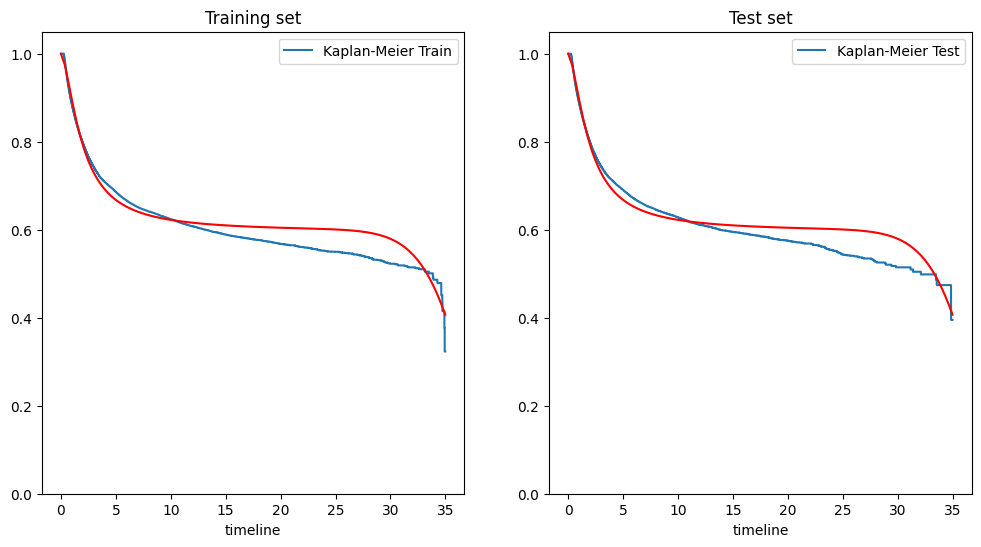

In [20]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

# Custom Mixture Birnbaum-Sanders

In [107]:
def build_custom_mixture_bs_model():
    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )

    parameters = {
        # Birnbaum-Sanders component
        "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        # Weibull component
        "alpha_ll": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 30.0, "warmup_time": 0},
        "beta_ll": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 2.0, "warmup_time": 0},
        # Mixture weight
        # "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0},
        "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "independent", "shape": 1, "init": 0.55, "warmup_time": 0}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        alpha = model.get_variable("alpha")
        beta = model.get_variable("beta")
        
        alpha_ll = model.get_variable("alpha_ll")
        beta_ll = model.get_variable("beta_ll")
        
        # w = model.get_variable("w", nn_output)
        w = model.get_variable("w")

        log_y = tf.math.log(y_safe)

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)        
        
        # Log-density and log-survival for the lognormal component
        S1 = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S1 = tf.math.log(S1 + eps)      

        pi = tf.cast(np.pi, dtype = tf.float32)
        term1 = tf.math.log(sqrt_y_beta + sqrt_beta_y + eps)
        term2 = -tf.math.log(2.0 * alpha * y_safe * tf.math.sqrt(2.0 * pi))
        term3 = -0.5 * (z ** 2.0)
        log_f1 = term1 + term2 + term3

        log_beta_ll = tf.math.log(beta_ll + eps)
        log_alpha_ll = tf.math.log(alpha_ll + eps)
        log_term_ll = tf.math.softplus( beta_ll * (log_y - log_alpha_ll) )
        log_f2 = log_beta_ll + (beta_ll-1) * log_y - beta_ll * log_alpha_ll - 2.0 * log_term_ll
        log_S2 = -log_term_ll

        # Apply the LogSumExp trick for the mixture density and survival logs, respectively
        log_w = tf.math.log(w + eps)
        log_1_minus_w = tf.math.log(1.0 - w + eps)
        f_stack = tf.concat([log_w + log_f1, log_1_minus_w + log_f2], axis=1)
        S_stack = tf.concat([log_w + log_S1, log_1_minus_w + log_S2], axis=1)

        log_f_mix = tf.math.reduce_logsumexp(f_stack, axis = 1, keepdims = True)
        log_S_mix = tf.math.reduce_logsumexp(S_stack, axis = 1, keepdims = True)
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f_mix + (1-delta) * log_S_mix
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik
    return parameters, loglikelihood_loss, None, None, None

In [108]:
with tf.device("/GPU:0"):
    custom_mixture_parameters, custom_mixture_loss, custom_mixture_neural_network, custom_mixture_call, custom_mixture_call_nolast = \
    build_custom_mixture_bs_model()
    seed = 10
    custom_mixture_bs_model = thf.ModelNN(custom_mixture_parameters, custom_mixture_loss,
                                          custom_mixture_neural_network, custom_mixture_call,
                                          custom_mixture_call_nolast, input_dim = (1,), seed = seed)
    custom_mixture_bs_model.train_model(epochs = 5000, x = None, data = data_train,
                                        shuffle = True,
                                        get_covariances = True,
                                        validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                        force_training_validation = False,
                                        optimizer_independent = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                                        optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                                        fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                        early_stopping = True, early_stopping_patience = 30,
                                        early_stopping_warmup = 10,
                                        reduce_lr = True, reduce_lr_warmup = 0,
                                        reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                                        reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                        deterministic = True,
                                        verbose = True, print_freq = 1)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 147 / 5000 ]  | Loss:  236788.438 | Best Loss:  236792.062 | Speed:  37  epoch/s    | Elapsed Time:  3.94401646  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 5.843 seconds.


In [109]:
alpha = custom_mixture_bs_model.predict("alpha")
beta = custom_mixture_bs_model.predict("beta")

alpha_ll = custom_mixture_bs_model.predict("alpha_ll")
beta_ll = custom_mixture_bs_model.predict("beta_ll")
w = custom_mixture_bs_model.predict("w")

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta = tf.math.sqrt(ts_grid / beta)
sqrt_beta_ts = tf.math.sqrt(beta / ts_grid)
z_ts = (1.0 / alpha) * (sqrt_ts_beta - sqrt_beta_ts)

S1_ts_train = 0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))
S2_ts_train = 1 / ( 1 + (ts_grid / alpha_ll)**beta_ll )
S_ts_train = w * S1_ts_train + (1 - w) * S2_ts_train

# S1_ts_test = 0.5 * (1 - erf(np.log(ts_grid) - mu_test / sigma_test))
S1_ts_test = 0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))
S2_ts_test = 1 / ( 1 + (ts_grid / alpha_ll)**beta_ll )
S_ts_test = w * S1_ts_test + (1 - w) * S2_ts_test

print("alpha:", alpha)
print("beta:", beta)
print("alpha_ll:", alpha_ll)
print("beta_ll:", beta_ll)
print("w:", w)

alpha: [1.0070426]
beta: [1.659563]
alpha_ll: [62.940506]
beta_ll: [1.6892995]
w: [0.3537892]


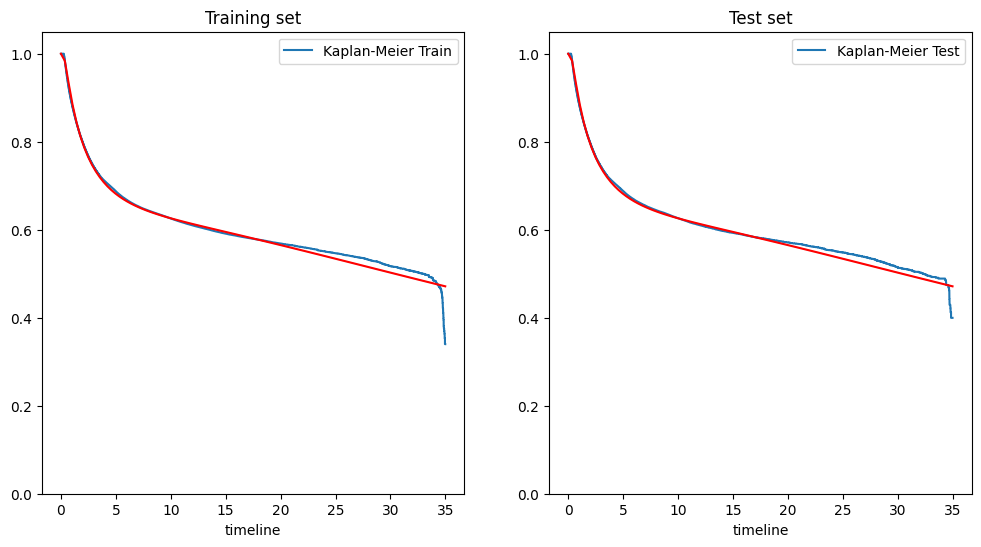

In [110]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

# Structure with covariates

In [ ]:
def build_custom_mixture_model(ridge_penalty=1e-4, lasso_penalty=1e-4):
    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )
    
    # parameters = {
    #     # Lognormal component
    #     "mu": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
    #     "sigma": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
    #     # Weibull component
    #     "k": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 30.0, "warmup_time": 0},
    #     "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 35.0, "warmup_time": 0},
    #     # Mixture weight
    #     # "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0},
    #     "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "independent", "shape": 1, "init": 0.55, "warmup_time": 1200}
    # }
    parameters = {
        # Loglogistic component
        "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
        "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
        # Weibull component
        "k": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 30.0, "warmup_time": 0},
        "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 35.0, "warmup_time": 0},
        # Mixture weight
        # "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0},
        "w": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "independent", "shape": 1, "init": 0.55, "warmup_time": 1200}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # mu = model.get_variable("mu", nn_output)
        # sigma = model.get_variable("sigma", nn_output)

        alpha = model.get_variable("alpha", nn_output)
        beta = model.get_variable("beta", nn_output)
        
        # sigma = model.get_variable("sigma")
        k = model.get_variable("k", nn_output)
        # k = model.get_variable("k")
        lam = model.get_variable("lam", nn_output)
        # w = model.get_variable("w", nn_output)
        w = model.get_variable("w")

        log_y = tf.math.log(y_safe)
        # z = (log_y - mu) / sigma
        
        # Log-density and log-survival for the lognormal component
        # value_2pi = 2.0 * tf.cast(np.pi, dtype = tf.float32)
        # log_f1 = -log_y - tf.math.log(sigma+eps) - tf.math.log(value_2pi) / 2.0 - z**2.0 / 2.0
        # log_S1 = tf.math.log( 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0)) + eps )

        log_beta = tf.math.log(beta + eps)
        log_alpha = tf.math.log(alpha + eps)
        log_term = tf.math.softplus( beta * (log_y - log_alpha) )
        log_f1 = log_beta + (beta-1) * log_y - beta * log_alpha - 2.0 * log_term
        log_S1 = -log_term

        # Log-density and log-survival for the weibull component
        log_S2 = -(y_safe / lam)**k
        log_f2 = tf.math.log(k+eps) - k * tf.math.log(lam) + (k-1)*log_y + log_S2

        # Apply the LogSumExp trick for the mixture density and survival logs, respectively
        log_w = tf.math.log(w + eps)
        log_1_minus_w = tf.math.log(1.0 - w + eps)
        f_stack = tf.concat([log_w + log_f1, log_1_minus_w + log_f2], axis=1)
        S_stack = tf.concat([log_w + log_S1, log_1_minus_w + log_S2], axis=1)

        log_f_mix = tf.math.reduce_logsumexp(f_stack, axis = 1, keepdims = True)
        log_S_mix = tf.math.reduce_logsumexp(S_stack, axis = 1, keepdims = True)
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f_mix + (1-delta) * log_S_mix
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.GlorotNormal(seed = seed)
        elastic_net = tf.keras.regularizers.L1L2(l1 = lasso_penalty, l2 = ridge_penalty)
        
        model.dense1 = layers.Dense(128, activation = "gelu", kernel_initializer = initializer, kernel_regularizer = elastic_net)
        model.dense2 = layers.Dense(64, activation = "gelu", kernel_initializer = initializer)
        model.dense3 = layers.Dense(32, activation = "gelu", kernel_initializer = initializer)
        model.dense4 = layers.Dense(8, activation = "gelu", kernel_initializer = initializer)
        
        model.output_layer = layers.Dense(4, activation = None, kernel_initializer = initializer, name = "mixture_parameters_output")
    
    def neural_network_call(model, x_input, training=False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [ ]:
with tf.device("/GPU:0"):
    custom_mixture_parameters, custom_mixture_loss, custom_mixture_neural_network, custom_mixture_call, custom_mixture_call_nolast = \
    build_custom_mixture_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
    seed = 10
    custom_mixture_model = thf.ModelNN(custom_mixture_parameters, custom_mixture_loss,
                                       custom_mixture_neural_network, custom_mixture_call,
                                       custom_mixture_call_nolast, input_dim = (n_features,), seed = seed)
    custom_mixture_model.pre_train_model(epochs = None, x = X_train, data = data_train, shuffle = True)
    # custom_mixture_model.pre_train_model(epochs = None, x = None, data = data_train, shuffle = True)
    custom_mixture_model.train_model(epochs = 1200, x = X_train, data = data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                early_stopping = True, early_stopping_patience = 30,
                                early_stopping_warmup = 10,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                fine_tune = True,
                                finetune_early_stopping = True, finetune_early_stopping_patience = 30,
                                finetune_early_stopping_warmup = 10,
                                finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 2, finetune_reduce_lr_patience = 25,
                                finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

In [ ]:
utils.plot_model_convergence( custom_mixture_model )

In [ ]:
pars_train = custom_mixture_model.predict(X_train)
pars_test = custom_mixture_model.predict(X_test)

# mu_train = pars_train["mu"].numpy().flatten()
# mu_test = pars_test["mu"].numpy().flatten()
# sigma_train = pars_train["sigma"].numpy().flatten()
# sigma_test = pars_test["sigma"].numpy().flatten()

alpha_train = pars_train["alpha"].numpy().flatten()
alpha_test = pars_test["alpha"].numpy().flatten()
beta_train = pars_train["beta"].numpy().flatten()
beta_test = pars_test["beta"].numpy().flatten()

k_train = pars_train["k"].numpy().flatten()
k_test = pars_test["k"].numpy().flatten()
lam_train = pars_train["lam"].numpy().flatten()
lam_test = pars_test["lam"].numpy().flatten()

w_train = custom_mixture_model.predict("w")
w_test = w_train.copy()
# w_train = pars_train["w"].numpy().flatten()
# w_test = pars_test["w"].numpy().flatten()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

# S1_ts_train = 0.5 * (1 - erf(np.log(ts_grid) - mu_train / sigma_train))
# S2_ts_train = np.exp( -(ts_grid / lam_train)**k_train )

S1_ts_train = 1 / ( 1 + (ts_grid / alpha_train)**beta_train )
S2_ts_train = np.exp( -(ts_grid / lam_train)**k_train )
S_ts_train = w_train * S1_ts_train + (1 - w_train) * S2_ts_train

# S1_ts_test = 0.5 * (1 - erf(np.log(ts_grid) - mu_test / sigma_test))
S1_ts_test = 1 / ( 1 + (ts_grid / alpha_test)**beta_test )
S2_ts_test = np.exp( -(ts_grid / lam_test)**k_test )
S_ts_test = w_test * S1_ts_test + (1 - w_test) * S2_ts_test

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()